# Eksperimen Preprocessing - California Housing Dataset

**Nama:** Louis-Hutapea  
**Tanggal:** 2026-05-30  
**Dataset:** California Housing (sklearn.datasets)  

---

## Deskripsi Proyek

Notebook ini berisi eksperimen preprocessing untuk dataset **California Housing**. Dataset ini berisi informasi sensus perumahan di California berdasarkan data sensus 1990. Target variabel adalah **median house value** (MedHouseVal) untuk setiap distrik.

### Fitur Dataset:
| No | Fitur | Deskripsi |
|---|---|---|
| 1 | MedInc | Median pendapatan di blok |
| 2 | HouseAge | Median usia rumah di blok |
| 3 | AveRooms | Rata-rata jumlah ruangan per rumah tangga |
| 4 | AveBedrms | Rata-rata jumlah kamar tidur per rumah tangga |
| 5 | Population | Populasi blok |
| 6 | AveOccup | Rata-rata jumlah anggota rumah tangga |
| 7 | Latitude | Lintang blok |
| 8 | Longitude | Bujur blok |

**Target:** MedHouseVal (Median nilai rumah dalam ratusan ribu dolar)

### Tahapan Eksperimen:
1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Simpan Hasil
5. Download File (khusus Colab)
6. Kesimpulan

---
## 0. Import Library

In [1]:
# Import library yang diperlukan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Deteksi apakah berjalan di Google Colab atau Lokal
try:
    import google.colab
    IS_COLAB = True
    BASE_DIR = '/content'
    print('\u2601 Berjalan di Google Colab')
except ImportError:
    IS_COLAB = False
    BASE_DIR = os.getcwd()
    print('\U0001f4bb Berjalan di Lokal')

# Pengaturan visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

import warnings
warnings.filterwarnings('ignore')

print(f"Base directory: {BASE_DIR}")
print("Library berhasil di-import! \u2713")

☁ Berjalan di Google Colab
Base directory: /content
Library berhasil di-import! ✓


---
## 1. Data Loading

Pada tahap ini, kita akan memuat dataset California Housing dari `sklearn.datasets` dan menyimpannya sebagai file CSV mentah.

In [2]:
# Memuat dataset California Housing dari sklearn
housing = fetch_california_housing(as_frame=True)

# Gabungkan fitur dan target menjadi satu DataFrame
df = housing.frame

print("Dataset berhasil dimuat!")
print(f"Shape: {df.shape}")
print(f"Jumlah sampel: {df.shape[0]}")
print(f"Jumlah fitur: {df.shape[1] - 1} + 1 target")

Dataset berhasil dimuat!
Shape: (20640, 9)
Jumlah sampel: 20640
Jumlah fitur: 8 + 1 target


In [3]:
# Simpan data mentah ke file CSV
# Path otomatis menyesuaikan apakah di Colab atau Lokal
if IS_COLAB:
    raw_data_dir = os.path.join(BASE_DIR, 'california_housing_raw')
else:
    raw_data_dir = os.path.join('..', 'california_housing_raw')
os.makedirs(raw_data_dir, exist_ok=True)

raw_csv_path = os.path.join(raw_data_dir, 'housing_raw.csv')
df.to_csv(raw_csv_path, index=False)

print(f"Data mentah disimpan ke: {raw_csv_path}")
print(f"Ukuran file: {os.path.getsize(raw_csv_path) / 1024:.2f} KB")

Data mentah disimpan ke: /content/california_housing_raw/housing_raw.csv
Ukuran file: 1850.74 KB


In [4]:
# Tampilkan 5 baris pertama
print("5 Baris Pertama Dataset:")
df.head()

5 Baris Pertama Dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
# Tampilkan 5 baris terakhir
print("5 Baris Terakhir Dataset:")
df.tail()

5 Baris Terakhir Dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


---
## 2. Exploratory Data Analysis (EDA)

Pada tahap ini kita akan melakukan eksplorasi data untuk memahami karakteristik dataset sebelum preprocessing.

### 2.1 Informasi Dasar Dataset

In [6]:
# Informasi tipe data dan memory usage
print("=" * 50)
print("INFORMASI DATASET")
print("=" * 50)
df.info()

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
# Statistik deskriptif
print("Statistik Deskriptif:")
df.describe().round(4)

Statistik Deskriptif:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000
mean,3.8707,28.6395,5.4290,1.0967,1425.4767,3.0707,35.6319,-119.5697,2.0686
std,1.8998,12.5856,2.4742,0.4739,1132.4621,10.3860,2.1360,2.0035,1.1540
min,0.4999,1.0000,0.8462,0.3333,3.0000,0.6923,32.5400,-124.3500,0.1500
25%,2.5634,18.0000,4.4407,1.0061,787.0000,2.4297,33.9300,-121.8000,1.1960
50%,3.5348,29.0000,5.2291,1.0488,1166.0000,2.8181,34.2600,-118.4900,1.7970
75%,4.7432,37.0000,6.0524,1.0995,1725.0000,3.2823,37.7100,-118.0100,2.6472
max,15.0001,52.0000,141.9091,34.0667,35682.0000,1243.3333,41.9500,-114.3100,5.0000


In [8]:
# Shape dataset
print(f"Shape dataset: {df.shape}")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

Shape dataset: (20640, 9)
Jumlah baris: 20640
Jumlah kolom: 9


### 2.2 Cek Missing Values

In [9]:
# Cek missing values
print("Missing Values per Kolom:")
print("-" * 30)
missing_values = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing (%)': missing_pct
})
print(missing_df)
print(f"\nTotal missing values: {missing_values.sum()}")

if missing_values.sum() == 0:
    print("\n\u2705 Tidak ada missing values pada dataset ini.")
else:
    print("\n\u26a0\ufe0f Terdapat missing values yang perlu ditangani.")

Missing Values per Kolom:
------------------------------
             Missing Count  Missing (%)
MedInc                   0          0.0
HouseAge                 0          0.0
AveRooms                 0          0.0
AveBedrms                0          0.0
Population               0          0.0
AveOccup                 0          0.0
Latitude                 0          0.0
Longitude                0          0.0
MedHouseVal              0          0.0

Total missing values: 0

✅ Tidak ada missing values pada dataset ini.


In [10]:
# Cek data duplikat
duplicates = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicates}")

if duplicates == 0:
    print("\u2705 Tidak ada data duplikat.")
else:
    print(f"\u26a0\ufe0f Terdapat {duplicates} baris duplikat.")

Jumlah baris duplikat: 0
✅ Tidak ada data duplikat.


### 2.3 Distribusi Setiap Fitur

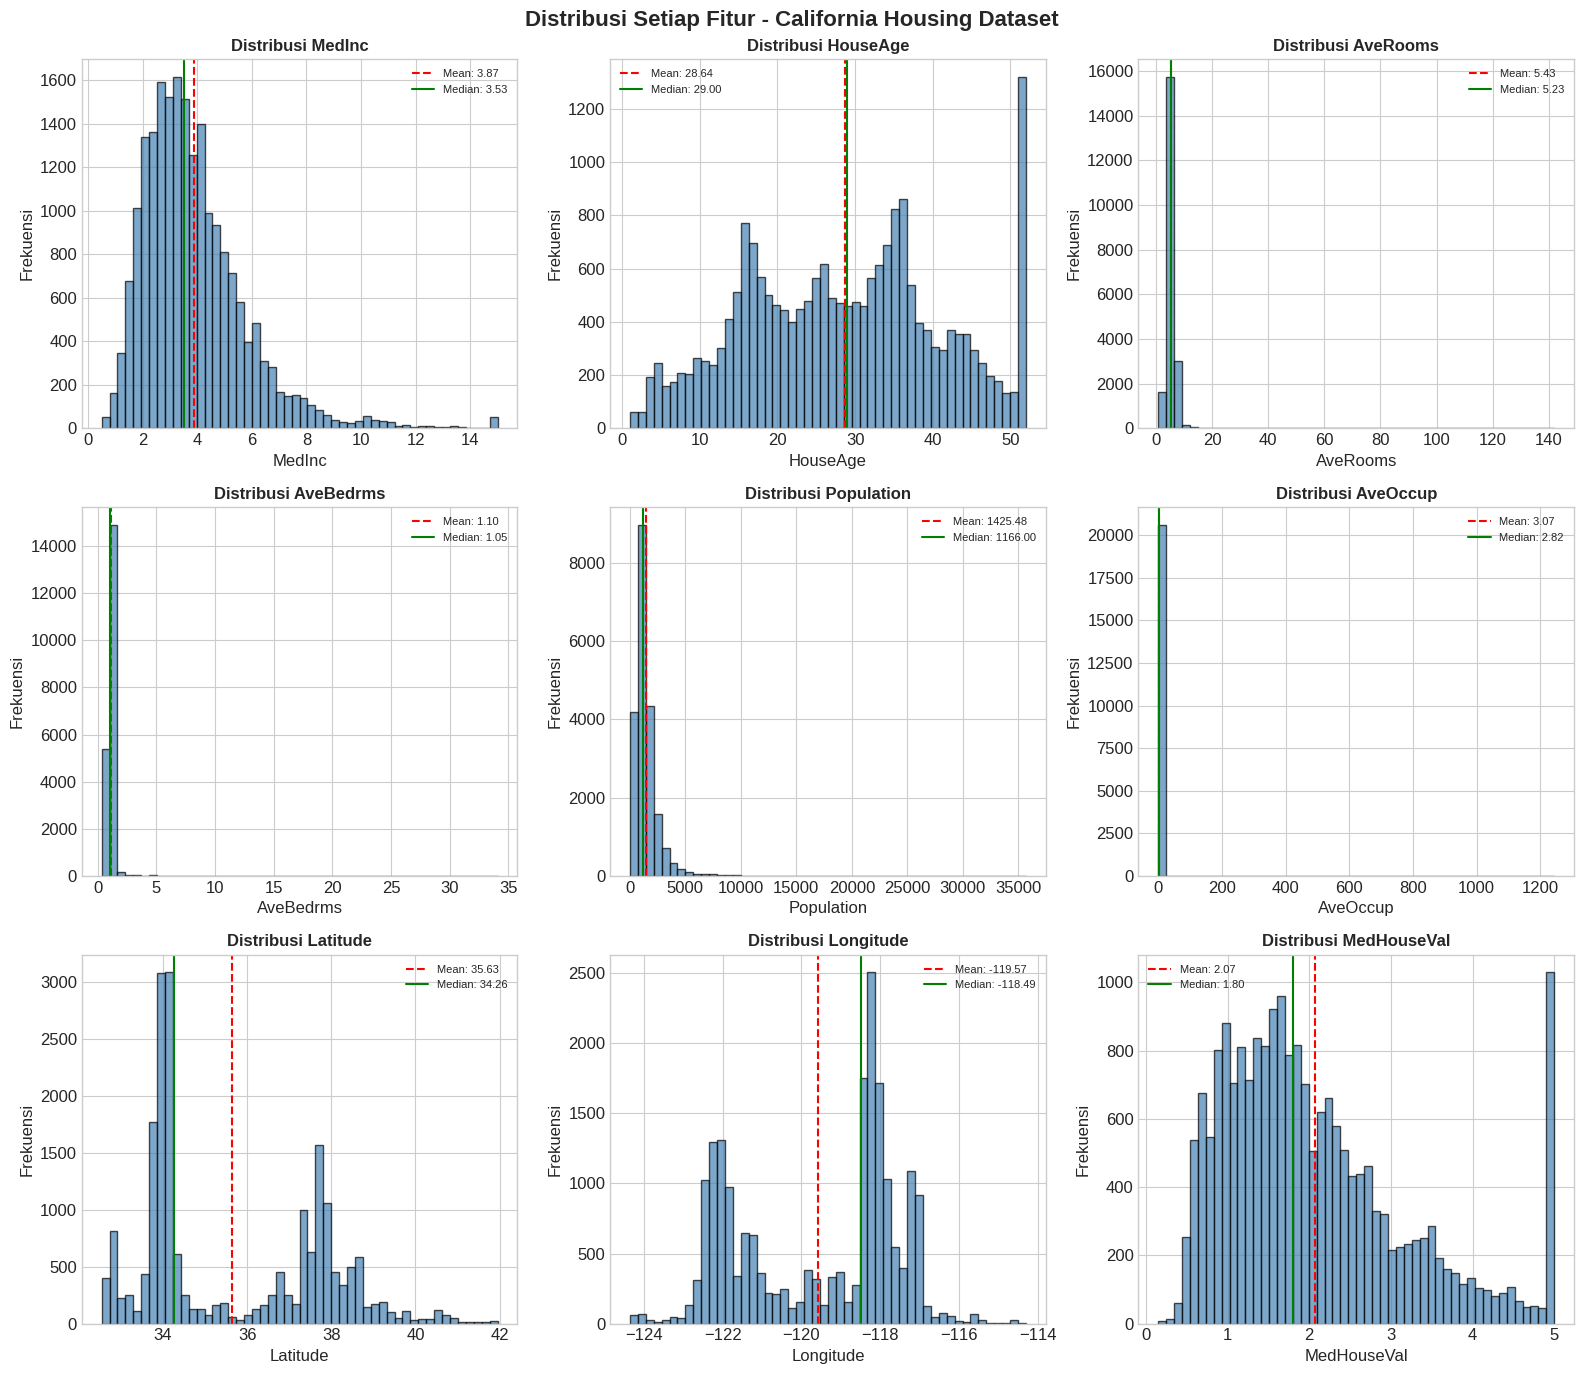

In [11]:
# Visualisasi distribusi setiap fitur menggunakan histogram
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('Distribusi Setiap Fitur - California Housing Dataset', fontsize=16, fontweight='bold')

columns = df.columns.tolist()

for idx, col in enumerate(columns):
    row = idx // 3
    col_idx = idx % 3
    ax = axes[row, col_idx]

    ax.hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')

    # Tambahkan garis mean dan median
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='green', linestyle='-', linewidth=1.5, label=f'Median: {df[col].median():.2f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 2.4 Correlation Heatmap

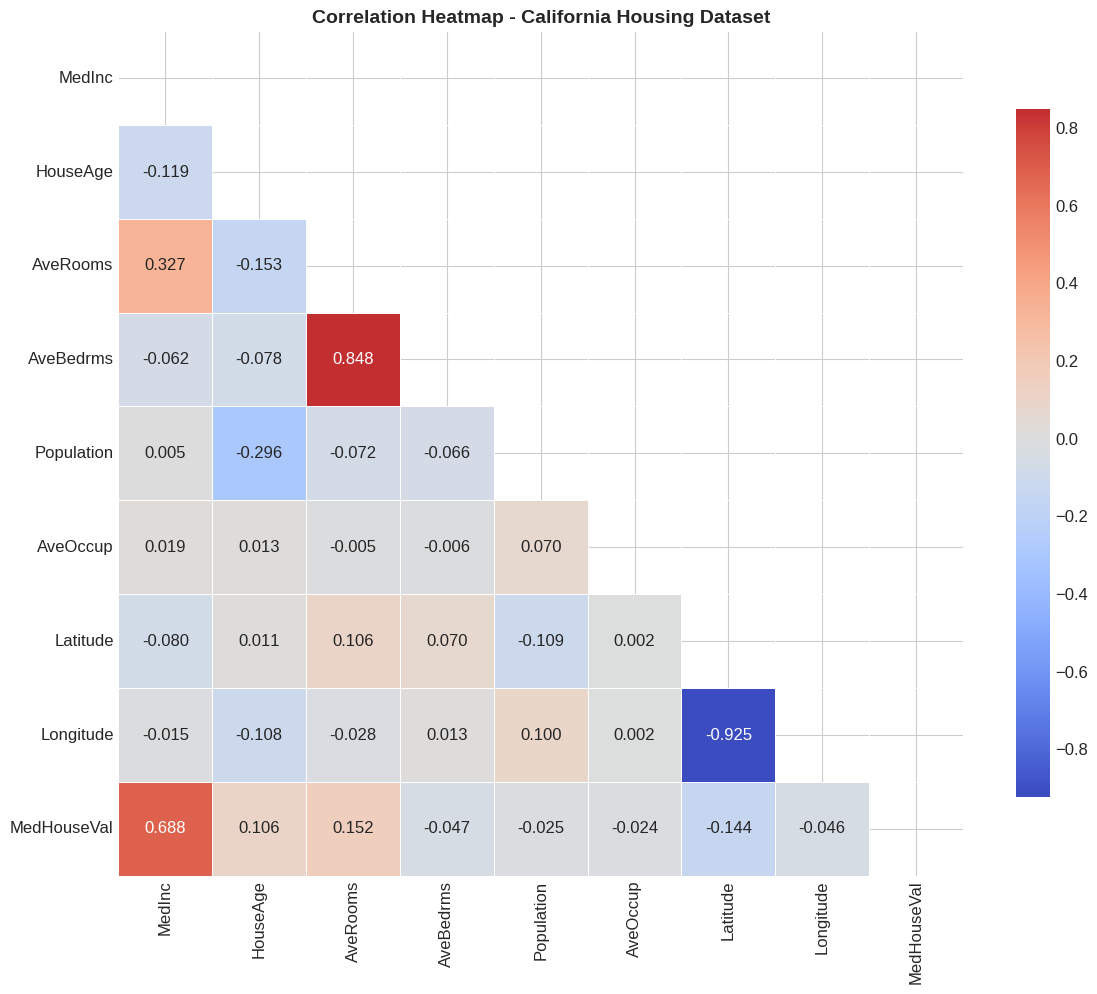


Korelasi fitur terhadap target (MedHouseVal):
---------------------------------------------
  MedInc         : +0.6881
  AveRooms       : +0.1519
  HouseAge       : +0.1056
  AveOccup       : -0.0237
  Population     : -0.0246
  Longitude      : -0.0460
  AveBedrms      : -0.0467
  Latitude       : -0.1442


In [12]:
# Heatmap korelasi antar fitur
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    mask=mask,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap - California Housing Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Korelasi terhadap target
print("\nKorelasi fitur terhadap target (MedHouseVal):")
print("-" * 45)
target_corr = correlation_matrix['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False)
for feature, corr in target_corr.items():
    print(f"  {feature:15s}: {corr:+.4f}")

### 2.5 Deteksi Outlier dengan Boxplot

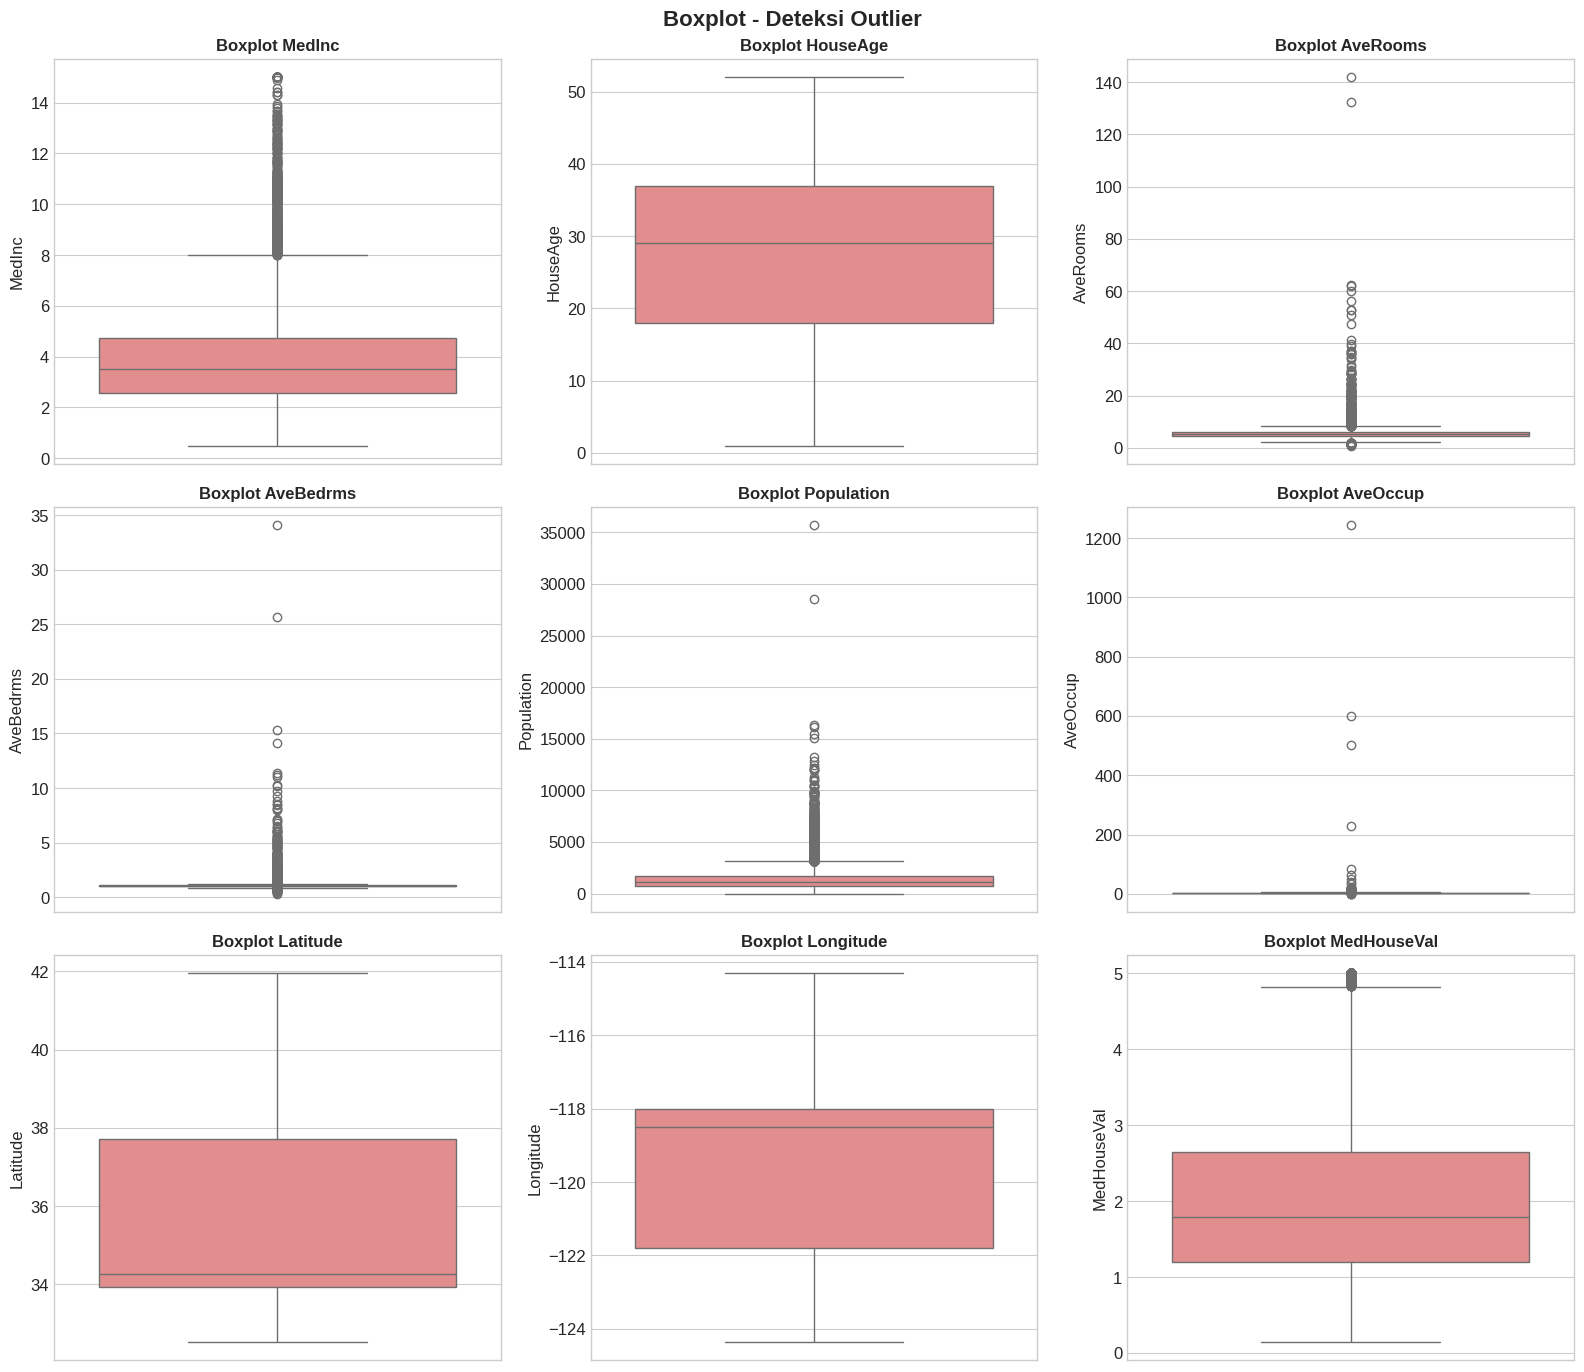

In [13]:
# Boxplot untuk deteksi outlier
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('Boxplot - Deteksi Outlier', fontsize=16, fontweight='bold')

for idx, col in enumerate(columns):
    row = idx // 3
    col_idx = idx % 3
    ax = axes[row, col_idx]

    sns.boxplot(data=df, y=col, ax=ax, color='lightcoral')
    ax.set_title(f'Boxplot {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

In [14]:
# Hitung jumlah outlier per fitur menggunakan IQR method
print("Deteksi Outlier (Metode IQR):")
print("=" * 60)

feature_cols = [col for col in df.columns if col != 'MedHouseVal']

outlier_summary = []
for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = (outliers / len(df) * 100)

    outlier_summary.append({
        'Fitur': col,
        'Q1': round(Q1, 4),
        'Q3': round(Q3, 4),
        'IQR': round(IQR, 4),
        'Lower Bound': round(lower, 4),
        'Upper Bound': round(upper, 4),
        'Outliers': outliers,
        'Outliers (%)': round(pct, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

Deteksi Outlier (Metode IQR):


,Fitur,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Outliers (%)
0,MedInc,2.5634,4.7432,2.1798,-0.7064,8.0130,681,3.30
1,HouseAge,18.0000,37.0000,19.0000,-10.5000,65.5000,0,0.00
2,AveRooms,4.4407,6.0524,1.6117,2.0232,8.4699,511,2.48
3,AveBedrms,1.0061,1.0995,0.0934,0.8659,1.2397,1424,6.90
4,Population,787.0000,1725.0000,938.0000,-620.0000,3132.0000,1196,5.79
5,AveOccup,2.4297,3.2823,0.8525,1.1510,4.5610,711,3.44
6,Latitude,33.9300,37.7100,3.7800,28.2600,43.3800,0,0.00
7,Longitude,-121.8000,-118.0100,3.7900,-127.4850,-112.3250,0,0.00


### 2.6 Scatter Plot Fitur vs Target

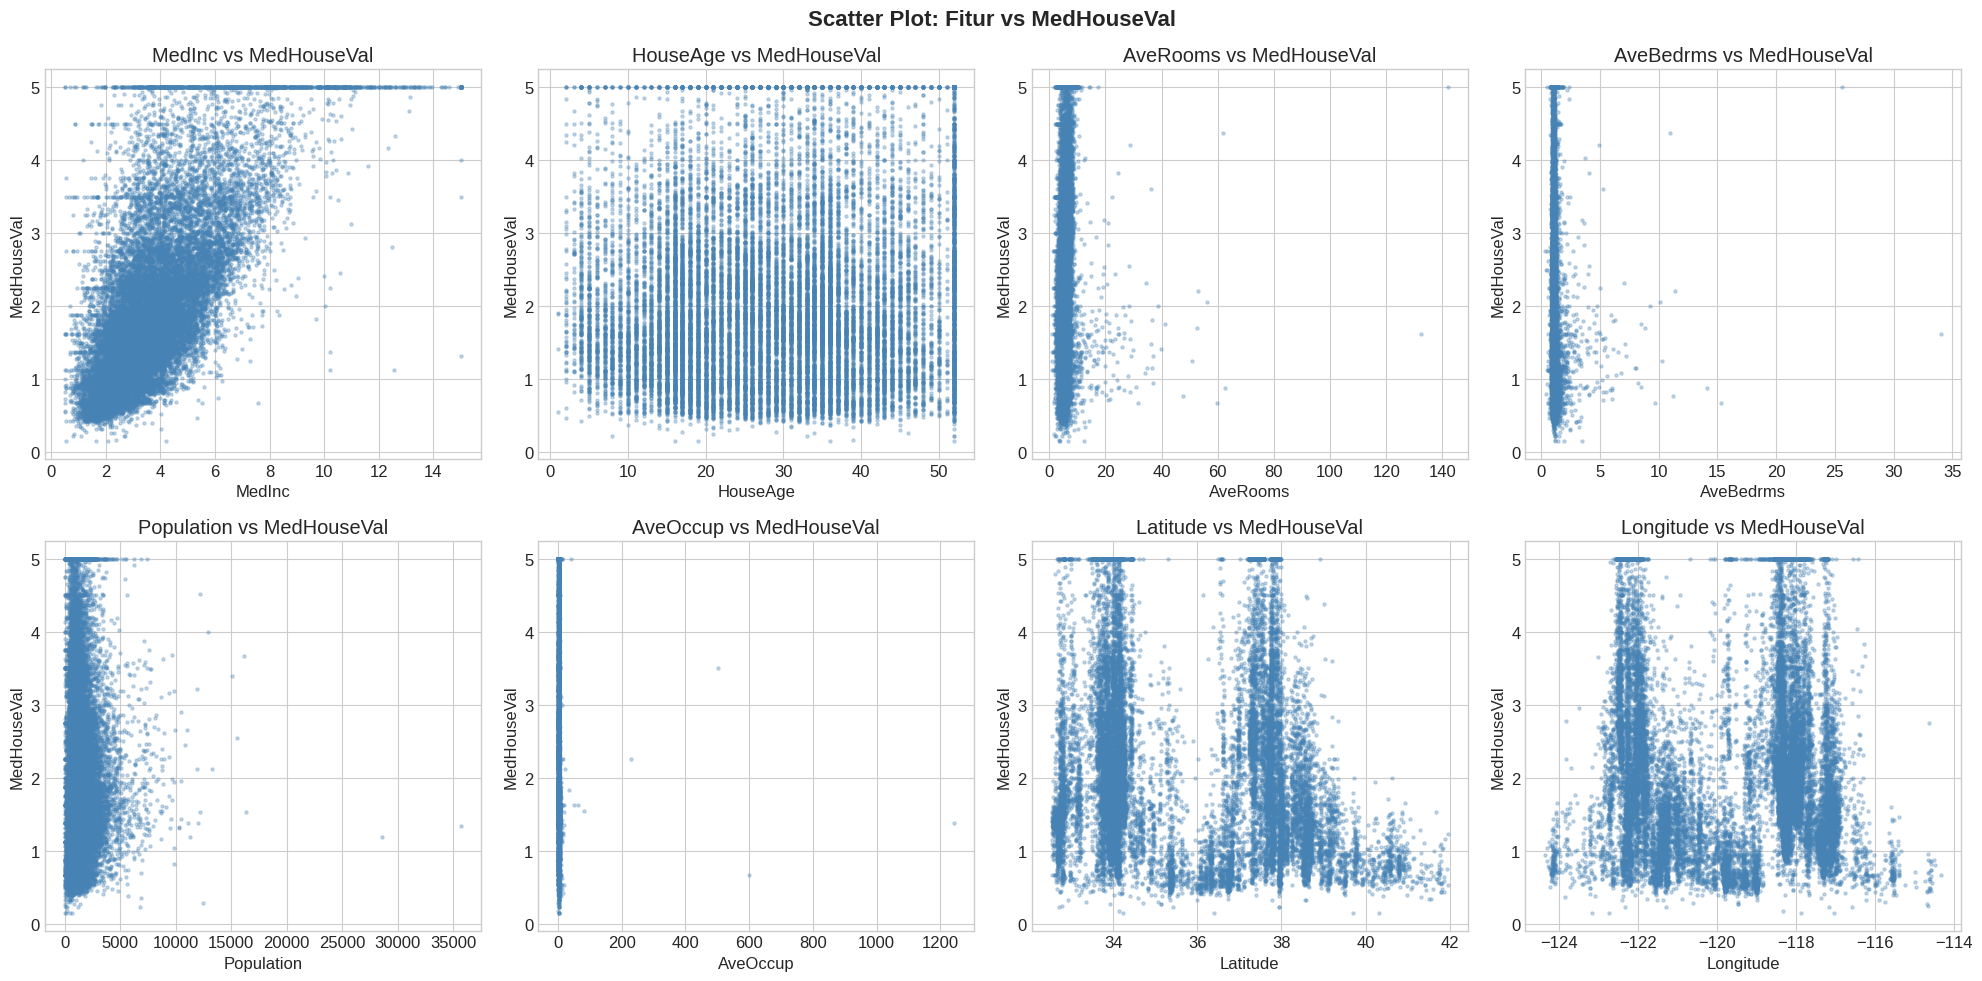

In [15]:
# Scatter plot fitur terhadap target
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Scatter Plot: Fitur vs MedHouseVal', fontsize=16, fontweight='bold')

for idx, col in enumerate(feature_cols):
    row = idx // 4
    col_idx = idx % 4
    ax = axes[row, col_idx]

    ax.scatter(df[col], df['MedHouseVal'], alpha=0.3, s=5, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('MedHouseVal')
    ax.set_title(f'{col} vs MedHouseVal')

plt.tight_layout()
plt.show()

---
## 3. Data Preprocessing

Berdasarkan hasil EDA, tahapan preprocessing yang akan dilakukan:
1. **Penanganan Outlier** menggunakan metode IQR (clipping/winsorization)
2. **Feature Scaling** menggunakan StandardScaler
3. **Train-Test Split** dengan rasio 80:20

### 3.1 Penanganan Outlier (Metode IQR - Clipping)

In [16]:
# Copy dataframe untuk preprocessing
df_clean = df.copy()

print(f"Jumlah data sebelum penanganan outlier: {len(df_clean)}")
print("\nMelakukan clipping outlier menggunakan IQR method...")
print("-" * 60)

# Terapkan IQR clipping pada setiap fitur
for col in feature_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Hitung outlier sebelum clipping
    outliers_before = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()

    # Clip outlier ke batas IQR
    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

    # Verifikasi
    outliers_after = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()

    if outliers_before > 0:
        print(f"  {col:15s}: {outliers_before:5d} outlier(s) di-clip -> {outliers_after} outlier(s) tersisa")

print(f"\nJumlah data setelah clipping: {len(df_clean)} (tidak ada data yang hilang)")

Jumlah data sebelum penanganan outlier: 20640

Melakukan clipping outlier menggunakan IQR method...
------------------------------------------------------------
  MedInc         :   681 outlier(s) di-clip -> 0 outlier(s) tersisa
  AveRooms       :   511 outlier(s) di-clip -> 0 outlier(s) tersisa
  AveBedrms      :  1424 outlier(s) di-clip -> 0 outlier(s) tersisa
  Population     :  1196 outlier(s) di-clip -> 0 outlier(s) tersisa
  AveOccup       :   711 outlier(s) di-clip -> 0 outlier(s) tersisa

Jumlah data setelah clipping: 20640 (tidak ada data yang hilang)


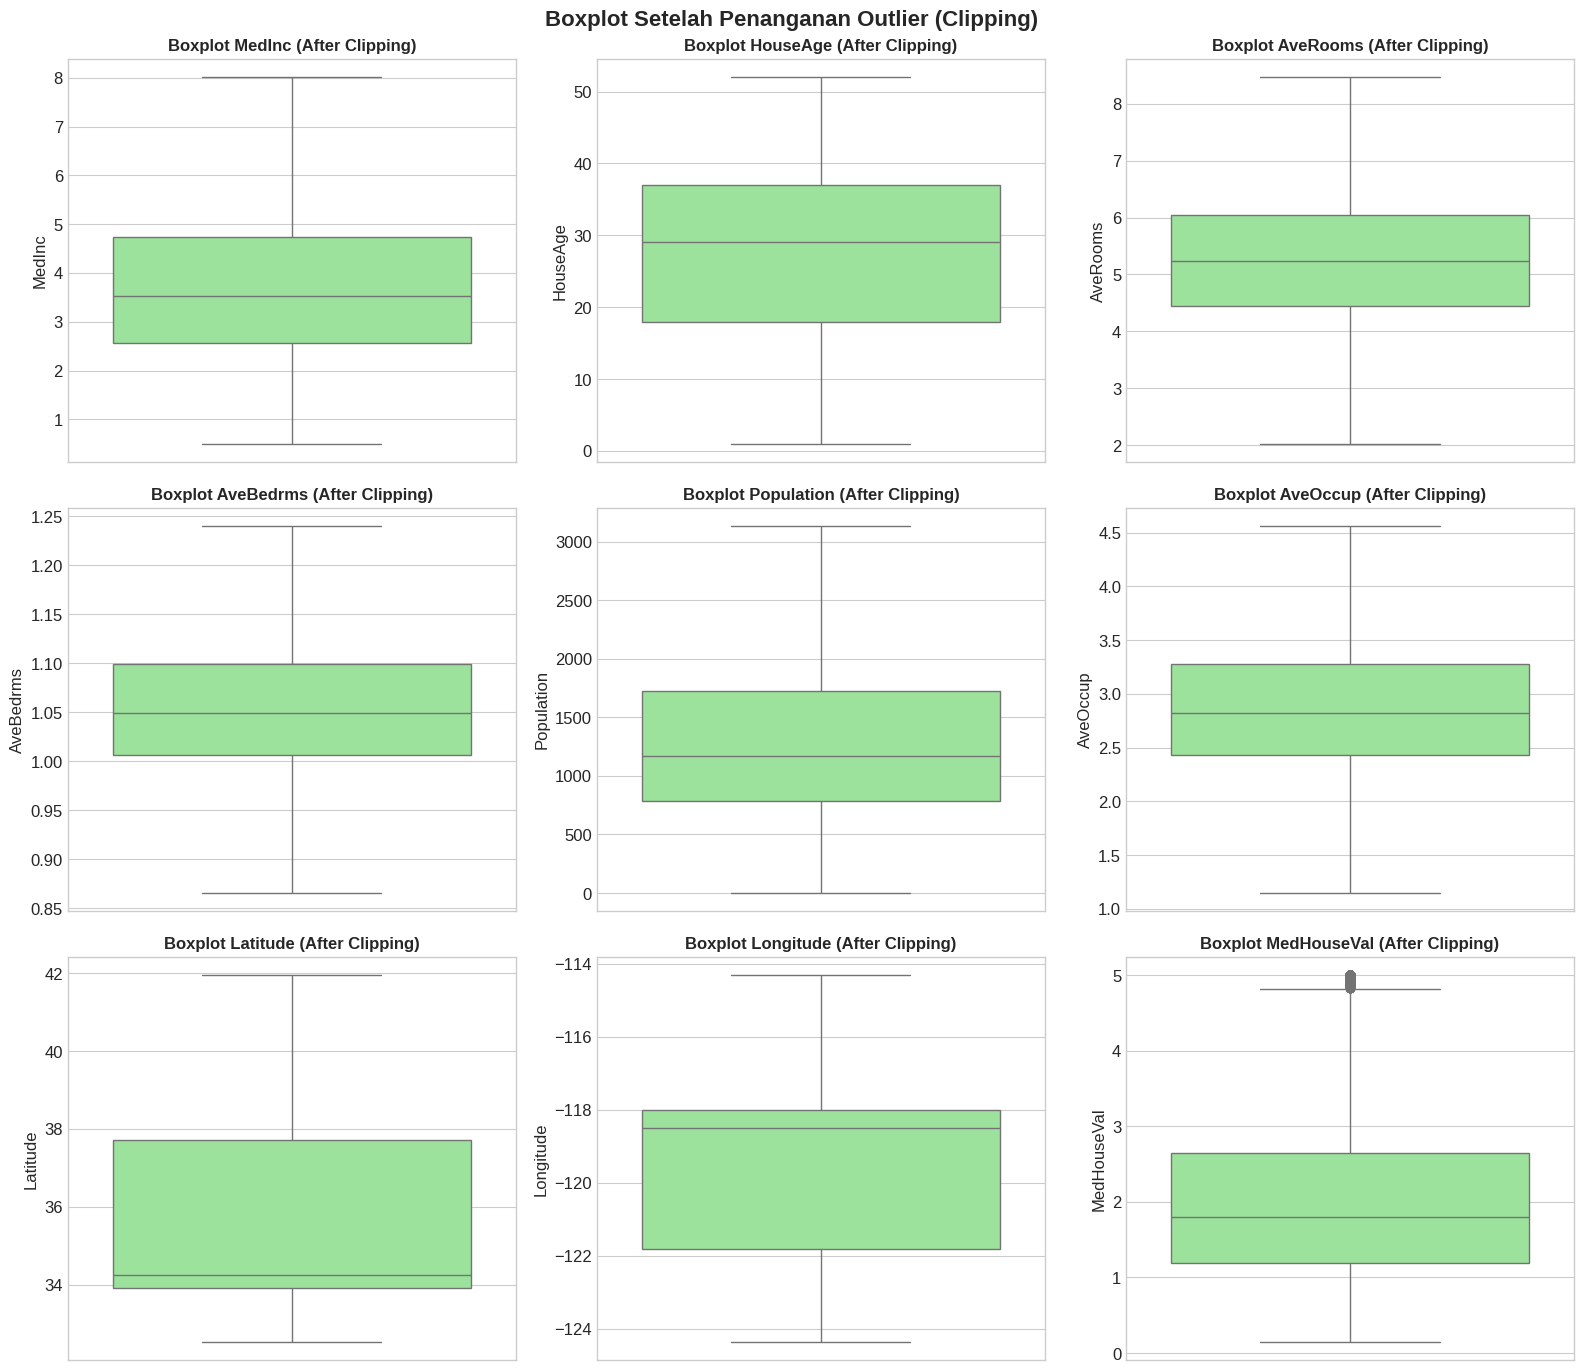

In [17]:
# Verifikasi: Boxplot setelah clipping
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('Boxplot Setelah Penanganan Outlier (Clipping)', fontsize=16, fontweight='bold')

for idx, col in enumerate(df_clean.columns.tolist()):
    row = idx // 3
    col_idx = idx % 3
    ax = axes[row, col_idx]

    sns.boxplot(data=df_clean, y=col, ax=ax, color='lightgreen')
    ax.set_title(f'Boxplot {col} (After Clipping)', fontsize=12, fontweight='bold')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

### 3.2 Pisahkan Fitur dan Target

In [18]:
# Pisahkan fitur (X) dan target (y)
X = df_clean.drop(columns=['MedHouseVal'])
y = df_clean['MedHouseVal']

print(f"Fitur (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nDaftar fitur: {list(X.columns)}")
print(f"Target: MedHouseVal")

Fitur (X) shape: (20640, 8)
Target (y) shape: (20640,)

Daftar fitur: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: MedHouseVal


### 3.3 Train-Test Split (80:20)

In [19]:
# Train-Test Split dengan rasio 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train-Test Split (80:20):")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_test shape : {X_test.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  y_test shape : {y_test.shape}")
print(f"\n  Rasio train: {len(X_train)/len(X)*100:.1f}%")
print(f"  Rasio test : {len(X_test)/len(X)*100:.1f}%")

Train-Test Split (80:20):
  X_train shape: (16512, 8)
  X_test shape : (4128, 8)
  y_train shape: (16512,)
  y_test shape : (4128,)

  Rasio train: 80.0%
  Rasio test : 20.0%


### 3.4 Feature Scaling (StandardScaler)

In [20]:
# Feature Scaling menggunakan StandardScaler
# PENTING: fit pada training data saja, lalu transform pada train dan test
scaler = StandardScaler()

# Fit dan transform pada training data
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

# Transform pada test data (menggunakan parameter dari training)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Feature Scaling selesai!")
print("\nStatistik X_train setelah scaling:")
print(X_train_scaled.describe().round(4))

Feature Scaling selesai!

Statistik X_train setelah scaling:
           MedInc    HouseAge    AveRooms   AveBedrms  Population    AveOccup  \
count  16512.0000  16512.0000  16512.0000  16512.0000  16512.0000  16512.0000   
mean      -0.0000     -0.0000      0.0000     -0.0000      0.0000      0.0000   
std        1.0000      1.0000      1.0000      1.0000      1.0000      1.0000   
min       -1.9919     -2.1908     -2.6397     -2.3892     -1.7452     -2.5284   
25%       -0.7485     -0.8418     -0.6911     -0.6450     -0.7177     -0.6791   
50%       -0.1595      0.0311     -0.0622     -0.1143     -0.2236     -0.1170   
75%        0.5789      0.6659      0.5998      0.5191      0.5072      0.5528   
max        2.5279      1.8562      2.5323      2.2477      2.3452      2.4067   

         Latitude   Longitude  
count  16512.0000  16512.0000  
mean       0.0000      0.0000  
std        1.0000      1.0000  
min       -1.4477     -2.3772  
25%       -0.8018     -1.1107  
50%       -0.6474

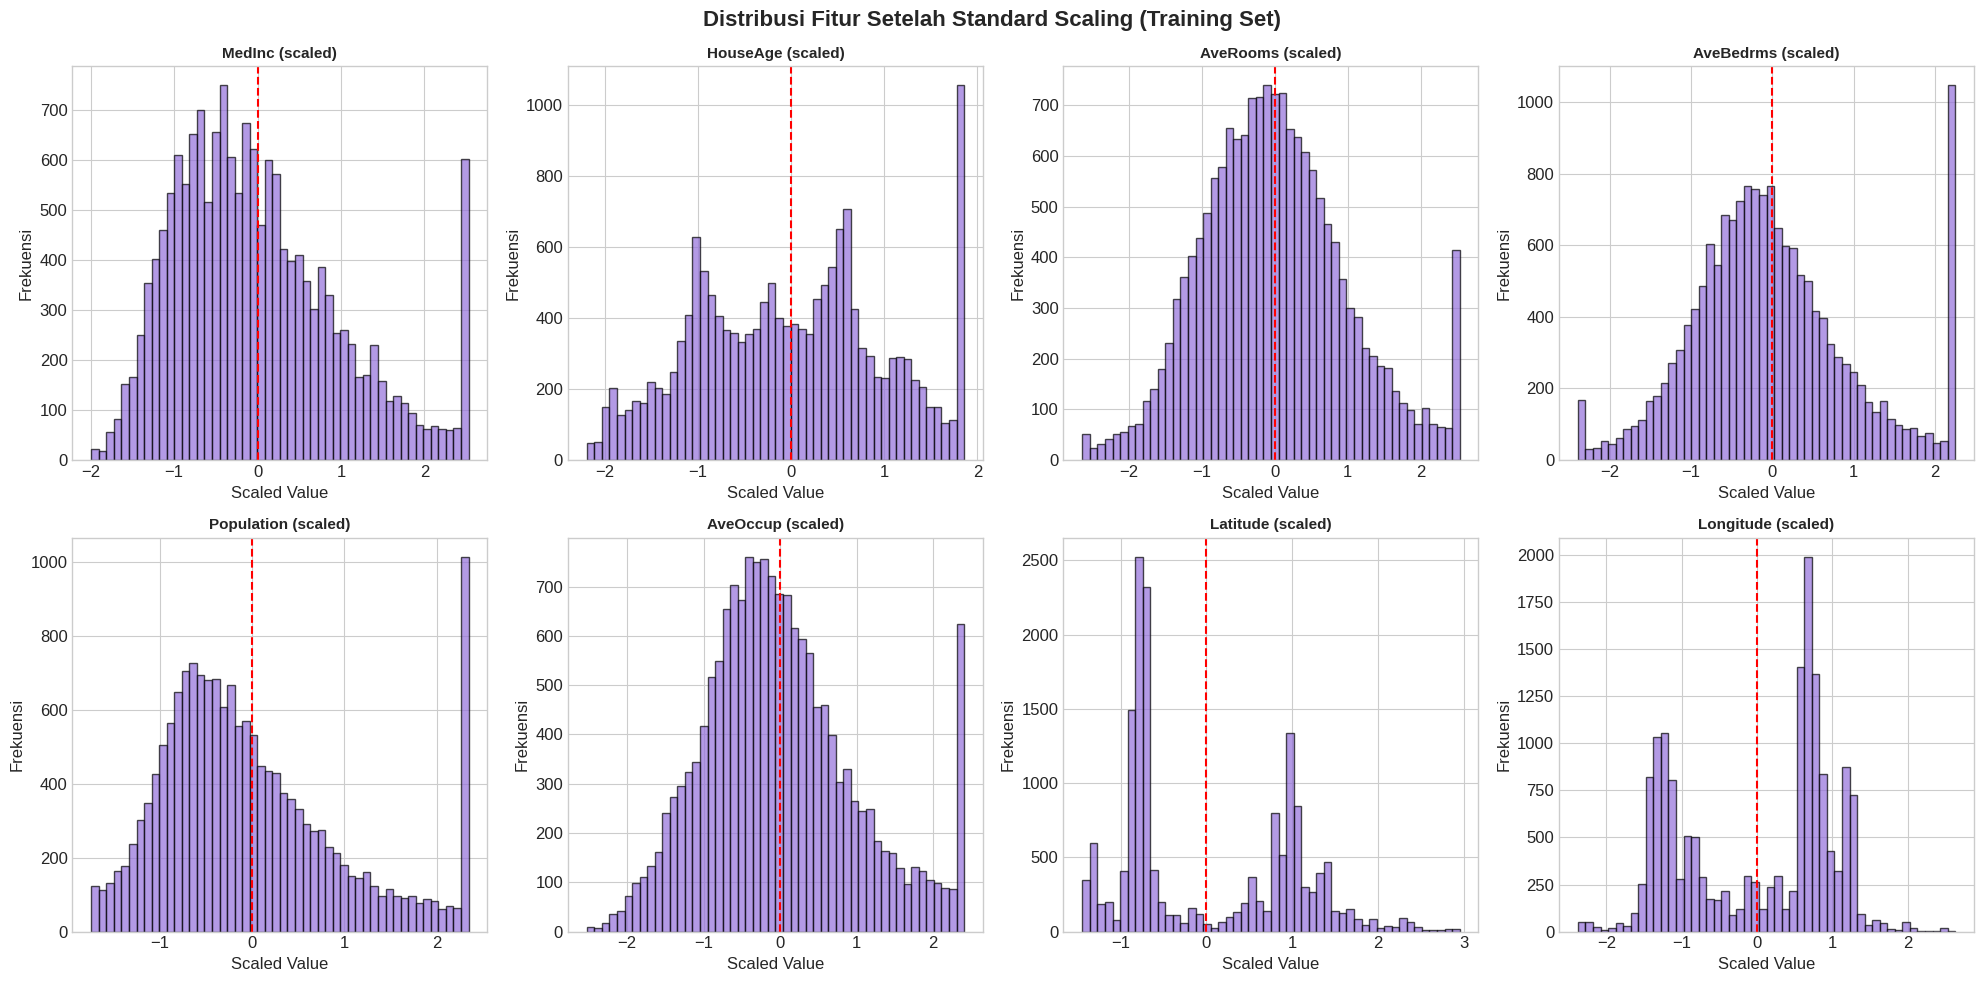

In [21]:
# Verifikasi: distribusi sebelum dan sesudah scaling
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Distribusi Fitur Setelah Standard Scaling (Training Set)', fontsize=16, fontweight='bold')

for idx, col in enumerate(X_train_scaled.columns):
    row = idx // 4
    col_idx = idx % 4
    ax = axes[row, col_idx]

    ax.hist(X_train_scaled[col], bins=50, edgecolor='black', alpha=0.7, color='mediumpurple')
    ax.set_title(f'{col} (scaled)', fontsize=11, fontweight='bold')
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Scaled Value')
    ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

---
## 4. Simpan Hasil Preprocessing

Menyimpan data hasil preprocessing ke file CSV untuk digunakan pada tahap selanjutnya (modelling).

In [22]:
# Buat direktori output
output_dir = 'california_housing_preprocessing'
os.makedirs(output_dir, exist_ok=True)

# Simpan masing-masing split
X_train_scaled.to_csv(os.path.join(output_dir, 'X_train.csv'), index=False)
X_test_scaled.to_csv(os.path.join(output_dir, 'X_test.csv'), index=False)
y_train.to_csv(os.path.join(output_dir, 'y_train.csv'), index=False, header=True)
y_test.to_csv(os.path.join(output_dir, 'y_test.csv'), index=False, header=True)

# Simpan data gabungan preprocessed
df_preprocessed = pd.concat([
    pd.DataFrame(
        scaler.transform(X),
        columns=X.columns,
        index=X.index
    ),
    y.reset_index(drop=True)
], axis=1)
df_preprocessed.to_csv(os.path.join(output_dir, 'housing_preprocessed.csv'), index=False)

print("File berhasil disimpan:")
for f in os.listdir(output_dir):
    filepath = os.path.join(output_dir, f)
    size_kb = os.path.getsize(filepath) / 1024
    print(f"  \u2713 {f} ({size_kb:.2f} KB)")

File berhasil disimpan:
  ✓ y_train.csv (95.67 KB)
  ✓ y_test.csv (23.90 KB)
  ✓ X_train.csv (2529.88 KB)
  ✓ housing_preprocessed.csv (3282.16 KB)
  ✓ X_test.csv (632.79 KB)


In [23]:
# Verifikasi: baca kembali data yang sudah disimpan
X_train_check = pd.read_csv(os.path.join(output_dir, 'X_train.csv'))
X_test_check = pd.read_csv(os.path.join(output_dir, 'X_test.csv'))
y_train_check = pd.read_csv(os.path.join(output_dir, 'y_train.csv'))
y_test_check = pd.read_csv(os.path.join(output_dir, 'y_test.csv'))

print("Verifikasi data yang disimpan:")
print(f"  X_train: {X_train_check.shape}")
print(f"  X_test : {X_test_check.shape}")
print(f"  y_train: {y_train_check.shape}")
print(f"  y_test : {y_test_check.shape}")
print("\n\u2705 Semua data berhasil disimpan dan diverifikasi!")

Verifikasi data yang disimpan:
  X_train: (16512, 8)
  X_test : (4128, 8)
  y_train: (16512, 1)
  y_test : (4128, 1)

✅ Semua data berhasil disimpan dan diverifikasi!


---
## 5. Download File (Khusus Google Colab)

Jika Anda menjalankan notebook ini di Google Colab, jalankan cell di bawah untuk mendownload semua file hasil preprocessing ke komputer lokal.

In [24]:
# Download file dari Colab ke komputer lokal
# Cell ini HANYA berjalan di Google Colab, di lokal akan di-skip otomatis
if IS_COLAB:
    import shutil
    from google.colab import files

    # Zip seluruh folder preprocessing
    zip_name = 'california_housing_hasil_preprocessing'
    shutil.make_archive(zip_name, 'zip', '.', 'california_housing_preprocessing')

    # Zip folder raw data juga
    raw_zip = 'california_housing_raw_data'
    if os.path.exists(raw_data_dir):
        shutil.make_archive(raw_zip, 'zip', os.path.dirname(raw_data_dir), 'california_housing_raw')

    print('Mendownload file...')
    files.download(f'{zip_name}.zip')
    files.download(f'{raw_zip}.zip')
    print('\u2705 Download selesai! Ekstrak file zip di komputer lokal Anda.')
else:
    print('Berjalan di lokal - file sudah tersimpan di direktori kerja.')
    print(f'Folder preprocessed: {os.path.abspath(output_dir)}')
    print(f'Folder raw data: {os.path.abspath(raw_data_dir)}')

Mendownload file...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download selesai! Ekstrak file zip di komputer lokal Anda.


---
## 6. Kesimpulan

### Ringkasan Eksperimen Preprocessing:

1. **Dataset:** California Housing dari sklearn dengan 20.640 sampel dan 8 fitur + 1 target (MedHouseVal)

2. **Temuan EDA:**
   - Tidak ada missing values pada dataset
   - Beberapa fitur memiliki distribusi yang skewed (AveRooms, AveBedrms, Population, AveOccup)
   - Fitur MedInc memiliki korelasi positif tertinggi terhadap target MedHouseVal
   - Terdapat outlier signifikan pada beberapa fitur (terutama AveRooms, AveBedrms, Population, AveOccup)

3. **Preprocessing yang dilakukan:**
   - **Penanganan Outlier:** Metode IQR dengan clipping (winsorization) untuk mempertahankan jumlah data
   - **Feature Scaling:** StandardScaler (z-score normalization) dengan fit pada training data
   - **Train-Test Split:** 80:20 dengan random_state=42 untuk reproducibility

4. **Hasil:**
   - Data training: ~16.512 sampel
   - Data testing: ~4.128 sampel
   - Semua fitur ter-scaled dengan mean ≈ 0 dan std ≈ 1 pada training set
   - Data siap digunakan untuk tahap modelling

### File Output:
- `california_housing_preprocessing/X_train.csv`
- `california_housing_preprocessing/X_test.csv`
- `california_housing_preprocessing/y_train.csv`
- `california_housing_preprocessing/y_test.csv`
- `california_housing_preprocessing/housing_preprocessed.csv`